In [1]:
import numpy as np
from tensorflow.keras.models import load_model
import hls4ml
from qkeras.utils import _add_supported_quantized_objects

2026-05-07 16:02:38.646317: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
Matplotlib created a temporary config/cache directory at /tmp/matplotlib-04pi5d2n because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


/opt/conda/lib/python3.10/site-packages/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


In [2]:
resolution = 150

#model_orig = load_model(f'unpruned_model_{resolution}.h5')
co = {}
_add_supported_quantized_objects(co)
model_orig = load_model(f"hgdream_new/quantized_model_opt_{resolution}.h5", custom_objects=co)
model_final = load_model(f"hgdream_new/quantized_model_opt_{resolution}_pruned.h5", custom_objects=co)

hls_config = hls4ml.utils.config_from_keras_model(
    model_final,
    granularity='name',
    backend='Vivado',
    default_precision='ap_fixed<14,8>'
)
hls_model = hls4ml.converters.convert_from_keras_model(
    model_final,
    hls_config=hls_config,
    backend='Vivado',
    output_dir='model_final',
    part='xcu250-figd2104-2L-e',
    io_type='io_stream',
)
hls_model.compile()

hls_config1 = hls4ml.utils.config_from_keras_model(
    model_final,
    granularity='name',
    backend='Vivado',
    default_precision='ap_fixed<16,8>'
)
hls_model1 = hls4ml.converters.convert_from_keras_model(
    model_final,
    hls_config=hls_config1,
    backend='Vivado',
    output_dir='model_final',
    part='xcu250-figd2104-2L-e',
    io_type='io_stream',
)
hls_model1.compile()

X_total = np.load(f"Data/X_Data_Bank_{resolution}.npy")
Y_total = np.load(f"Data/Y_Data_Bank_{resolution}.npy")
X_test = X_total[1500:2000,:,:]
Y_test = Y_total[1500:2000,:,:]
NUM_EVENTS = 500
TIME_STEPS = int(12000/resolution)

2026-05-07 16:02:42.607866: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Interpreting Sequential
Topology:
Layer name: input_3, layer type: InputLayer, input shapes: [[None, 80, 1]], output shape: [None, 80, 1]
Layer name: q_conv1d_10, layer type: QConv1D, input shapes: [[None, 80, 1]], output shape: [None, 80, 32]
Layer name: q_activation_10, layer type: Activation, input shapes: [[None, 80, 32]], output shape: [None, 80, 32]
Layer name: q_conv1d_11, layer type: QConv1D, input shapes: [[None, 80, 32]], output shape: [None, 40, 32]
Layer name: q_activation_11, layer type: Activation, input shapes: [[None, 40, 32]], output shape: [None, 40, 32]
Layer name: q_conv1d_12, layer type: QConv1D, input shapes: [[None, 40, 32]], output shape: [None, 40, 64]
Layer name: q_activation_12, layer type: Activation, input shapes: [[None, 40, 64]], output shape: [None, 40, 64]
Layer name: up_sampling1d_2, layer type: UpSampling1D, input shapes: [[None, 40, 64]], output shape: [None, 80, 64]
Layer name: q_conv1d_13, layer type: QConv1D, input shapes: [[None, 80, 64]], output

Done
Interpreting Sequential
Topology:
Layer name: input_3, layer type: InputLayer, input shapes: [[None, 80, 1]], output shape: [None, 80, 1]
Layer name: q_conv1d_10, layer type: QConv1D, input shapes: [[None, 80, 1]], output shape: [None, 80, 32]
Layer name: q_activation_10, layer type: Activation, input shapes: [[None, 80, 32]], output shape: [None, 80, 32]
Layer name: q_conv1d_11, layer type: QConv1D, input shapes: [[None, 80, 32]], output shape: [None, 40, 32]
Layer name: q_activation_11, layer type: Activation, input shapes: [[None, 40, 32]], output shape: [None, 40, 32]
Layer name: q_conv1d_12, layer type: QConv1D, input shapes: [[None, 40, 32]], output shape: [None, 40, 64]
Layer name: q_activation_12, layer type: Activation, input shapes: [[None, 40, 64]], output shape: [None, 40, 64]
Layer name: up_sampling1d_2, layer type: UpSampling1D, input shapes: [[None, 40, 64]], output shape: [None, 80, 64]
Layer name: q_conv1d_13, layer type: QConv1D, input shapes: [[None, 80, 64]], o

Done


In [4]:
Y_test_reduced = Y_test
for i in range(NUM_EVENTS):
    for j in range(TIME_STEPS):
        if Y_test_reduced[i][j]!=0:
            Y_test_reduced[i][j]=1
y_predict_original = model_orig.predict(X_test)
'''
for i in range(NUM_EVENTS):
    for j in range(TIME_STEPS):
        if y_predict_original[i][j]!=0:
            y_predict_original[i][j]=1'''
            
predict_baseline=Y_test
test_score_baseline=model_orig.evaluate(X_test,Y_test)

y_predict_final =model_final.predict(X_test)
#test_score_final =model_final.evaluate(X_test,Y_test)

y_predict_hls = hls_model.predict(X_test)
y_predict_hls1 = hls_model1.predict(X_test)
'''for i in range(NUM_EVENTS):
    for j in range(TIME_STEPS):
        #print(y_predict_hls4ml[i][j])
        if y_predict_pooling[i][j]!=0:
            y_predict_pooling[i][j]=1'''

'''
y_predict_hls4ml = hls_model.predict((X_test_reduced))
for i in range(NUM_EVENTS):
    for j in range(TIME_STEPS):
        print(y_predict_hls4ml[i][j])
        if y_predict_hls4ml[i][j]!=0:
            y_predict_hls4ml[i][j]=1'''

16/16 [==============================] - 0s 3ms/step


'\ny_predict_hls4ml = hls_model.predict((X_test_reduced))\nfor i in range(NUM_EVENTS):\n    for j in range(TIME_STEPS):\n        print(y_predict_hls4ml[i][j])\n        if y_predict_hls4ml[i][j]!=0:\n            y_predict_hls4ml[i][j]=1'

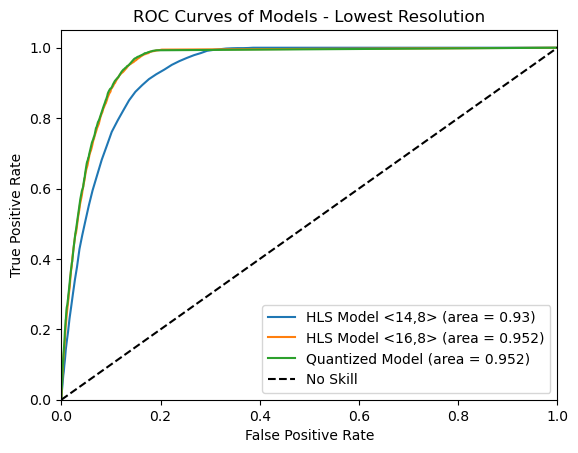

In [5]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
def plotROC_Comparison(Y_test_reduced,Y_predict_1, Y_predict_2, Y_predict_3):
    plt.figure()  
    fpr, tpr, thresholds = roc_curve(Y_test_reduced.flatten(), Y_predict_1.flatten()) 
    roc_auc = auc(fpr, tpr)
    fpr1, tpr1, thresholds1 = roc_curve(Y_test_reduced.flatten(), Y_predict_2.flatten())
    roc_auc1=auc(fpr1,tpr1)
    fpr2, tpr2, thresholds2 = roc_curve(Y_test_reduced.flatten(), Y_predict_3.flatten())
    roc_auc2=auc(fpr2,tpr2)
    roc_auc = int(roc_auc * 1000) / 1000
    roc_auc1 = int(roc_auc1 * 1000) / 1000
    roc_auc2 = int(roc_auc2 * 1000) / 1000
    plt.plot(fpr, tpr, label=f'HLS Model <14,8> (area = {roc_auc})')
    plt.plot(fpr1, tpr1, label=f'HLS Model <16,8> (area = {roc_auc1})')
    plt.plot(fpr2, tpr2, label=f'Quantized Model (area = {roc_auc2})')
    plt.title("ROC Curves of Models - Lowest Resolution")
    plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.savefig("ROC Curve Final Model",pad_inches=0.1)
    plt.show()
plotROC_Comparison(Y_test_reduced,y_predict_hls, y_predict_hls1, y_predict_final)

In [ ]:
def displayModel(index, X_data_ex, y_data_ex, name):
    fig, ax1 = plt.subplots()
    ax1.set_xlabel("time (~ns)")
    ax1.set_ylabel('Simulated Signal', color = 'tab:blue') 
    ax1.set_ylim(-5,30)
    ax1.plot(np.arange(0.0, TIME_STEPS * 0.2, 0.2),X_data_ex[index,:], "C0-")
    
    ax2 = ax1.twinx()
    ax2.set_ylabel("Model Pulse Location and Amplitude", color = 'tab:orange')
    ax2.set_ylim(-0.4,2.4)
    plt.plot(np.arange(0.0, TIME_STEPS * 0.2, 0.2),y_data_ex[index,:], "C1-", label = "Desired Output")
    plt.title("Model Predictions")
    plt.savefig(name, pad_inches=0.1)
    plt.show()

In [ ]:

displayModel(5,X_test,Y_test, "OriginalPulse.png")
displayModel(5,X_test,y_predict_final, "OriginalPulse.png")


#### 